<a href="https://colab.research.google.com/github/AliceNanL/BA820-project/blob/M1_Nan_Li/Copy_of_BA820_Cats_EDA_Nan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###UK Pet Cats GPS Tracking Data

1 - Domain
*   UK pet cat mobility dataset based on GPS tracking.
*   Goal: understand how domestic cats roam and move in the real world (unlabeled behavior traces).

2 - What it represents

(1) cats (event-level table)

*   Each row = one timestamped GPS ping for a cat

*   Includes latitude/longitude + data-quality flags (e.g., visible, outlier markers)

(2) cats_ref (cat-level reference table)

*   Each row = one cat (matched by tag_id)

*   Includes metadata such as sex, age, indoor hours, household context (e.g., number of cats), and hunting-related fields

3 - Data types included

*   Time series: timestamp (sequential pings)

*   Geospatial: location_lat, location_long

*   Categorical: visible, outlier flags, sex, hunting indicators, reproductive condition, food categories

*   Numeric: age, hours indoors, prey per month, household counts

4 - Approximate size & structure

*   Roughly 18,000 of GPS events in cats

*   Around ~100 cats in cats_ref

*   Structure is one-to-many: 1 cat → many GPS pings

5 - Stakeholders

*   Wildlife/ecology researchers: roaming patterns & potential predation impact

*   Animal welfare / NGOs: balancing outdoor access with safety and welfare

*   Local policy makers: evidence for community guidance or interventions

*   Cat owners / vets: understanding risk patterns and individual differences

6 - Why it’s interesting

It’s unlabeled real-world behavior to discover

*   natural mobility segments (e.g., home-body vs explorer)

*   similarity between cats’ roaming behaviors

*   extreme roaming cases

# **Data Loading**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
cats = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk.csv')
cats_ref = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk_reference.csv')

# **Data Cleaning**

**Check the `cats` dataset**

In [ ]:
cats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18215 entries, 0 to 18214
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tag_id                    18215 non-null  object 
 1   event_id                  18215 non-null  int64  
 2   visible                   18215 non-null  bool   
 3   timestamp                 18215 non-null  object 
 4   location_long             18215 non-null  float64
 5   location_lat              18215 non-null  float64
 6   ground_speed              18215 non-null  int64  
 7   height_above_ellipsoid    18215 non-null  float64
 8   algorithm_marked_outlier  18215 non-null  bool   
 9   manually_marked_outlier   18215 non-null  bool   
 10  study_name                18215 non-null  object 
dtypes: bool(3), float64(3), int64(2), object(3)
memory usage: 1.2+ MB


In [ ]:
cats.head(5)

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,study_name
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,Pet Cats United Kingdom
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,Pet Cats United Kingdom
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,Pet Cats United Kingdom
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,Pet Cats United Kingdom
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,Pet Cats United Kingdom


In [ ]:
#Check the type of value in tag_id column
cats["tag_id"].value_counts()

,count
tag_id,
Gracie_2-Tag,963
Bits-Tag,867
Teddy-Tag,791
Ginge-Tag,445
Maxwell-Tag,404
...,...
Felix-Tag,51
Tigger-Tag,51
Lily-Tag,46


In [ ]:
# Check if there are duplicates in tag_id, event_id,study_name in the dataset cats
print("Number of unique tag_id: {}".format(cats["tag_id"].nunique()))
print("Number of unique event_id: {}".format(cats["event_id"].nunique()))
print("Number of unique study_name: {}".format(cats["study_name"].nunique()))

Number of unique tag_id: 101
Number of unique event_id: 18215
Number of unique study_name: 1


In [ ]:
# We would like to keep the tag_id format consistent
cats["tag_id"] = cats["tag_id"].str.replace("-Tag", "", regex=False)
cats["tag_id"]

,tag_id
0,Ares
1,Ares
2,Ares
3,Ares
4,Ares
...,...
18210,Millie
18211,Millie
18212,Millie
18213,Millie


In [ ]:
cats["tag_id"].value_counts()

,count
tag_id,
Gracie_2,963
Bits,867
Teddy,791
Ginge,445
Maxwell,404
...,...
Felix,51
Tigger,51
Lily,46


In [ ]:
# Drop the study_name column in the cats dataset
cats = cats.drop(columns=["study_name"])
cats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18215 entries, 0 to 18214
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tag_id                    18215 non-null  object 
 1   event_id                  18215 non-null  int64  
 2   visible                   18215 non-null  bool   
 3   timestamp                 18215 non-null  object 
 4   location_long             18215 non-null  float64
 5   location_lat              18215 non-null  float64
 6   ground_speed              18215 non-null  int64  
 7   height_above_ellipsoid    18215 non-null  float64
 8   algorithm_marked_outlier  18215 non-null  bool   
 9   manually_marked_outlier   18215 non-null  bool   
dtypes: bool(3), float64(3), int64(2), object(2)
memory usage: 1.0+ MB


**Check the `cats_reference` dataset**

In [ ]:
cats_ref.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tag_id                         101 non-null    object 
 1   animal_id                      101 non-null    object 
 2   animal_taxon                   101 non-null    object 
 3   deploy_on_date                 101 non-null    object 
 4   deploy_off_date                101 non-null    object 
 5   hunt                           92 non-null     object 
 6   prey_p_month                   101 non-null    float64
 7   animal_reproductive_condition  98 non-null     object 
 8   animal_sex                     101 non-null    object 
 9   hrs_indoors                    101 non-null    float64
 10  n_cats                         101 non-null    int64  
 11  food_dry                       101 non-null    bool   
 12  food_wet                       101 non-null    boo

In [ ]:
# 1) Missingness + data quality flags
missing_cats = (cats.isna().mean().sort_values(ascending=False) * 100).round(2)
missing_ref = (cats_ref.isna().mean().sort_values(ascending=False) * 100).round(2)

print("Missingness (%) - cats (top 10):\n{}".format(missing_cats.head(10)))
print("\nMissingness (%) - cats_ref (top 10):\n{}".format(missing_ref.head(10)))

for col in ["visible", "algorithm_marked_outlier", "manually_marked_outlier"]:
    if col in cats.columns:
        print("\n{} value counts:\n{}".format(col, cats[col].value_counts(dropna=False)))


Missingness (%) - cats (top 10):
tag_id                      0.0
event_id                    0.0
visible                     0.0
timestamp                   0.0
location_long               0.0
location_lat                0.0
ground_speed                0.0
height_above_ellipsoid      0.0
algorithm_marked_outlier    0.0
manually_marked_outlier     0.0
dtype: float64

Missingness (%) - cats_ref (top 10):
food_other                       9.90
hunt                             8.91
animal_reproductive_condition    2.97
age_years                        0.99
deploy_on_date                   0.00
animal_taxon                     0.00
tag_id                           0.00
animal_id                        0.00
prey_p_month                     0.00
deploy_off_date                  0.00
dtype: float64

visible value counts:
visible
True     17866
False      349
Name: count, dtype: int64

algorithm_marked_outlier value counts:
algorithm_marked_outlier
False    18004
True       211
Name: count, dtyp

In [ ]:
cats_ref.head(5)

,tag_id,animal_id,animal_taxon,deploy_on_date,deploy_off_date,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,study_site,age_years
0,Tommy-Tag,Tommy,Felis catus,2017-06-03T01:02:09Z,2017-06-10T02:10:52Z,True,12.5,Neutered,m,12.5,2,True,True,False,UK,11.0
1,Athena,Athena,Felis catus,2017-06-24T01:02:13Z,2017-06-30T23:59:32Z,True,3.0,Spayed,f,7.5,2,True,True,False,UK,3.0
2,Ares,Ares,Felis catus,2017-06-24T01:03:57Z,2017-06-30T23:58:01Z,NaN,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
3,Lola,Lola,Felis catus,2017-06-24T01:18:49Z,2017-06-30T09:04:40Z,True,3.0,Spayed,f,17.5,1,True,True,False,UK,10.0
4,Maverick,Maverick,Felis catus,2017-06-25T01:04:35Z,2017-07-03T09:10:07Z,True,3.0,Neutered,m,12.5,1,True,True,True,UK,7.0


In [ ]:
# Check if there are duplicates in tag_id,animal_id, animal_taxon,animal_reproductive_condition, study_site in dataset cats_ref
print("Number of unique tag_id: {}".format(cats_ref["tag_id"].nunique()))
print("Number of unique animal_id: {}".format(cats_ref["animal_id"].nunique()))
print("Number of unique animal_taxon: {}".format(cats_ref["animal_taxon"].nunique()))
print("Number of unique animal_reproductive_condition: {}".format(cats_ref["animal_reproductive_condition"].nunique()))
print("Number of unique study_site: {}".format(cats_ref["study_site"].nunique()))

Number of unique tag_id: 101
Number of unique animal_id: 101
Number of unique animal_taxon: 1
Number of unique animal_reproductive_condition: 3
Number of unique study_site: 1


In [ ]:
# Drop the columns: animal_taxon,study_site
cats_ref = cats_ref.drop(columns=["animal_taxon","study_site"])


In [ ]:
#Check the types of values in animal_reprodcutive_taxon column
cats_ref["animal_reproductive_condition"].value_counts()


,count
animal_reproductive_condition,
Neutered,55
Spayed,41
Not fixed,2


In [ ]:
# in dataset cats_ref, get the rows where animal_reproduction_condition is neutered and animal_sex is f
label_error_m = cats_ref[(cats_ref["animal_reproductive_condition"] == "spayed") & (cats_ref["animal_sex"] == "m")]
label_error_f = cats_ref[(cats_ref["animal_reproductive_condition"] == "neutered") & (cats_ref["animal_sex"] == "f")]
print("Number of rows with label error for reproductive condition: {}".format(len(label_error_m) + len(label_error_f)))



Number of rows with label error for reproductive condition: 0


In [ ]:
cats_ref.loc[(cats_ref["animal_reproductive_condition"] == "Spayed") | (cats_ref["animal_reproductive_condition"] == "Neutered"), "animal_reproductive_condition"] = "Fixed"
cats_ref["animal_reproductive_condition"].value_counts()

,count
animal_reproductive_condition,
Fixed,96
Not fixed,2


In [ ]:
# Imputation on cats_ref: food_other, hunt, animal_reproductive_condition, age_years
# We inspect the distribution of these categorical variables with missing values
print("Hunt distribution:\n", cats_ref["hunt"].value_counts(dropna=False))
print("\nFood_other distribution:\n", cats_ref["food_other"].value_counts(dropna=False))
print("\nAnimal reproductive condition distribution:\n", cats_ref["animal_reproductive_condition"].value_counts(dropna=False))

Hunt distribution:
 hunt
True     81
False    11
NaN       9
Name: count, dtype: int64

Food_other distribution:
 food_other
False    49
True     42
NaN      10
Name: count, dtype: int64

Animal reproductive condition distribution:
 animal_reproductive_condition
Fixed        96
NaN           3
Not fixed     2
Name: count, dtype: int64


In [ ]:
# Impute the missing values of categorical variables by mode
cats_ref["hunt"].fillna(cats_ref["hunt"].mode()[0], inplace=True)
cats_ref["food_other"].fillna(cats_ref["food_other"].mode()[0], inplace=True)
cats_ref["animal_reproductive_condition"].fillna(cats_ref["animal_reproductive_condition"].mode()[0], inplace=True)

/tmp/ipython-input-4164074091.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cats_ref["hunt"].fillna(cats_ref["hunt"].mode()[0], inplace=True)
/tmp/ipython-input-4164074091.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cats_ref["hunt"].fillna(cats_ref["hunt"].mode()[0], inplace=True)
/tmp/ipython-inp

In [ ]:
# Impute the age_years by median
cats_ref["age_years"].fillna(cats_ref["age_years"].median(), inplace=True)


/tmp/ipython-input-3458866140.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cats_ref["age_years"].fillna(cats_ref["age_years"].median(), inplace=True)


In [ ]:
cats_ref.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tag_id                         101 non-null    object 
 1   animal_id                      101 non-null    object 
 2   deploy_on_date                 101 non-null    object 
 3   deploy_off_date                101 non-null    object 
 4   hunt                           101 non-null    bool   
 5   prey_p_month                   101 non-null    float64
 6   animal_reproductive_condition  101 non-null    object 
 7   animal_sex                     101 non-null    object 
 8   hrs_indoors                    101 non-null    float64
 9   n_cats                         101 non-null    int64  
 10  food_dry                       101 non-null    bool   
 11  food_wet                       101 non-null    bool   
 12  food_other                     101 non-null    boo

In [ ]:
cats_ref.head(15)

,tag_id,animal_id,deploy_on_date,deploy_off_date,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,age_years
0,Tommy-Tag,Tommy,2017-06-03T01:02:09Z,2017-06-10T02:10:52Z,True,12.5,Fixed,m,12.5,2,True,True,False,11.0
1,Athena,Athena,2017-06-24T01:02:13Z,2017-06-30T23:59:32Z,True,3.0,Fixed,f,7.5,2,True,True,False,3.0
2,Ares,Ares,2017-06-24T01:03:57Z,2017-06-30T23:58:01Z,True,0.0,Fixed,m,7.5,2,True,True,False,3.0
3,Lola,Lola,2017-06-24T01:18:49Z,2017-06-30T09:04:40Z,True,3.0,Fixed,f,17.5,1,True,True,False,10.0
4,Maverick,Maverick,2017-06-25T01:04:35Z,2017-07-03T09:10:07Z,True,3.0,Fixed,m,12.5,1,True,True,True,7.0
5,Coco,Coco,2017-06-28T01:02:22Z,2017-07-05T06:50:04Z,True,3.0,Fixed,f,12.5,2,True,True,True,7.0
6,Charlie,Charlie,2017-06-28T01:03:33Z,2017-07-04T07:08:31Z,True,3.0,Fixed,m,12.5,3,True,True,False,6.0
7,Jago,Jago,2017-06-28T04:10:59Z,2017-07-04T02:50:05Z,True,17.5,Fixed,m,7.5,4,True,True,True,2.0
8,Morpheus-Tag,Morpheus,2017-07-01T01:02:18Z,2017-07-09T06:39:05Z,True,3.0,Fixed,m,2.5,2,True,False,False,4.0
9,Nettle-Tag,Nettle,2017-07-01T01:05:50Z,2017-07-08T00:05:12Z,True,7.5,Fixed,f,12.5,2,True,False,False,4.0


In [ ]:
# Check if the values of tag_id matches the corresponding value of animal_id in each row
print("Number of rows where tag_id does not match animal_id: {}".format(len(cats_ref[cats_ref["tag_id"] != cats_ref["animal_id"]])))
#slice the dataset where the values of tag_id matches the corresponding value of animal_id in each row
cats_ref_sub = cats_ref[cats_ref["tag_id"] != cats_ref["animal_id"]]
cats_ref_sub

Number of rows where tag_id does not match animal_id: 93


,tag_id,animal_id,deploy_on_date,deploy_off_date,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,age_years
0,Tommy-Tag,Tommy,2017-06-03T01:02:09Z,2017-06-10T02:10:52Z,True,12.5,Fixed,m,12.5,2,True,True,False,11.0
8,Morpheus-Tag,Morpheus,2017-07-01T01:02:18Z,2017-07-09T06:39:05Z,True,3.0,Fixed,m,2.5,2,True,False,False,4.0
9,Nettle-Tag,Nettle,2017-07-01T01:05:50Z,2017-07-08T00:05:12Z,True,7.5,Fixed,f,12.5,2,True,False,False,4.0
10,Meg-Tag,Meg,2017-07-02T01:02:43Z,2017-07-09T00:36:13Z,True,3.0,Fixed,f,12.5,1,True,True,True,8.0
12,Carbonel-Tag,Carbonel,2017-07-07T01:01:46Z,2017-07-14T02:51:28Z,False,0.0,Fixed,m,17.5,1,True,False,False,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,Charlie3-Tag,Charlie3,2017-11-20T01:16:41Z,2017-11-26T00:38:20Z,True,7.5,Fixed,m,12.5,2,False,True,True,5.0
97,Millie-Tag,Millie,2017-11-20T01:38:55Z,2017-11-27T00:09:29Z,True,7.5,Fixed,f,12.5,2,False,True,True,3.0
98,SmokeyLongnose-Tag,SmokeyLongnose,2017-11-20T01:47:42Z,2017-11-27T02:53:41Z,True,0.5,Fixed,f,7.5,2,True,True,True,9.0
99,CJ-Tag,CJ,2017-11-24T06:48:32Z,2017-11-29T03:44:48Z,True,0.5,Fixed,m,22.5,2,True,True,False,5.0


In [ ]:
# Check if there is any value including Tag or tag in animal_id column
print("Number of rows where animal_id contains Tag or tag: {}".format(cats_ref[cats_ref["animal_id"].str.contains("Tag|tag")].shape[0]))

Number of rows where animal_id contains Tag or tag: 0


In [ ]:
# Since tag_id and animal_id contain identical information with different formats, we only keep animal_id column
cats_ref = cats_ref.drop(columns=["tag_id"])
cats_ref.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   animal_id                      101 non-null    object 
 1   deploy_on_date                 101 non-null    object 
 2   deploy_off_date                101 non-null    object 
 3   hunt                           101 non-null    bool   
 4   prey_p_month                   101 non-null    float64
 5   animal_reproductive_condition  101 non-null    object 
 6   animal_sex                     101 non-null    object 
 7   hrs_indoors                    101 non-null    float64
 8   n_cats                         101 non-null    int64  
 9   food_dry                       101 non-null    bool   
 10  food_wet                       101 non-null    bool   
 11  food_other                     101 non-null    bool   
 12  age_years                      101 non-null    flo

In [ ]:
# Get unique values from both columns
unique_tag_ids = set(cats["tag_id"].unique())
unique_animal_ids = set(cats_ref["animal_id"].unique())

# Check if the sets are identical
if unique_tag_ids == unique_animal_ids:
    print("The unique values in 'tag_id' (cats) and 'animal_id' (cats_ref) are identical.")
else:
    print("The unique values are NOT identical. Checking for differences...")
    # Find values present in cats['tag_id'] but not in cats_ref['animal_id']
    missing_in_cats_ref = unique_tag_ids - unique_animal_ids
    if missing_in_cats_ref:
        print(f"  Values in cats['tag_id'] not found in cats_ref['animal_id']: {missing_in_cats_ref}")

    # Find values present in cats_ref['animal_id'] but not in cats['tag_id']
    missing_in_cats = unique_animal_ids - unique_tag_ids
    if missing_in_cats:
        print(f"  Values in cats_ref['animal_id'] not found in cats['tag_id']: {missing_in_cats}")

The unique values in 'tag_id' (cats) and 'animal_id' (cats_ref) are identical.


In [ ]:
# Join the two datasets
cats = cats.rename(columns={'tag_id': 'animal_id'})
cats_sum = pd.merge(cats, cats_ref, on="animal_id", how="left")
cats_sum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18215 entries, 0 to 18214
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   animal_id                      18215 non-null  object 
 1   event_id                       18215 non-null  int64  
 2   visible                        18215 non-null  bool   
 3   timestamp                      18215 non-null  object 
 4   location_long                  18215 non-null  float64
 5   location_lat                   18215 non-null  float64
 6   ground_speed                   18215 non-null  int64  
 7   height_above_ellipsoid         18215 non-null  float64
 8   algorithm_marked_outlier       18215 non-null  bool   
 9   manually_marked_outlier        18215 non-null  bool   
 10  deploy_on_date                 18215 non-null  object 
 11  deploy_off_date                18215 non-null  object 
 12  hunt                           18215 non-null 

# **EDA**

### Exploratory Data Analysis Suggestions for `cats_sum`

Now that the `cats` and `cats_ref` datasets are merged into `cats_sum`, we have a richer dataset that combines GPS tracking information with cat-level metadata. Here are some key areas for EDA:

---

#### 1. Mobility Patterns and Cat Attributes (Associations)

*   **Question**: Are certain cat-level attributes (e.g., `animal_sex`, `age_years`, `hrs_indoors`, `n_cats`, `hunt`, `animal_reproductive_condition`, `food_dry`, `food_wet`, `food_other`) associated with different mobility patterns (e.g., total distance traveled, home range size, speed)?
*   **Methods**: Group data by cat attributes and analyze descriptive statistics of mobility metrics. Visualize these relationships using box plots, bar charts, or scatter plots.

---

#### 2. Time-Based Analysis

*   **Question**: How do mobility patterns (`ground_speed`, `location_long`, `location_lat`) vary by time of day or day of the week, and does this vary across different cat profiles (e.g., by `hrs_indoors` or `hunt` status)?
*   **Methods**: Extract hour of day and day of week from `timestamp`. Analyze average speed, distance from home (if home location is defined), or spread of locations over different time periods. Use line plots or heatmaps.

---

#### 3. Geospatial Analysis and Visualization

*   **Question**: What are the typical home ranges for cats? Are there differences in spatial distribution based on cat attributes?
*   **Methods**: Plot individual cat tracks on a map (e.g., using `folium` or `geopandas`). Calculate home range estimates (e.g., Minimum Convex Polygon, Kernel Density Estimation) for different cats or groups of cats and visualize them.

---

#### 4. Outlier and Anomaly Detection

*   **Question**: Can we identify unusual GPS pings (e.g., very high `ground_speed`, large displacement in a short time, unusual `height_above_ellipsoid` values) or cats with highly anomalous behavior?
*   **Methods**: Analyze distributions of `ground_speed` and `height_above_ellipsoid`. Calculate displacement between consecutive pings. Use statistical methods or visualization to identify outliers.

---

#### 5. Data Quality Flags Integration

*   **Question**: How do `visible`, `algorithm_marked_outlier`, and `manually_marked_outlier` flags correlate with other mobility metrics or cat attributes? Should these flagged points be treated differently?
*   **Methods**: Compare the distributions of `ground_speed`, displacement, etc., for flagged vs. unflagged points. Analyze the proportion of flagged points per cat or over time.


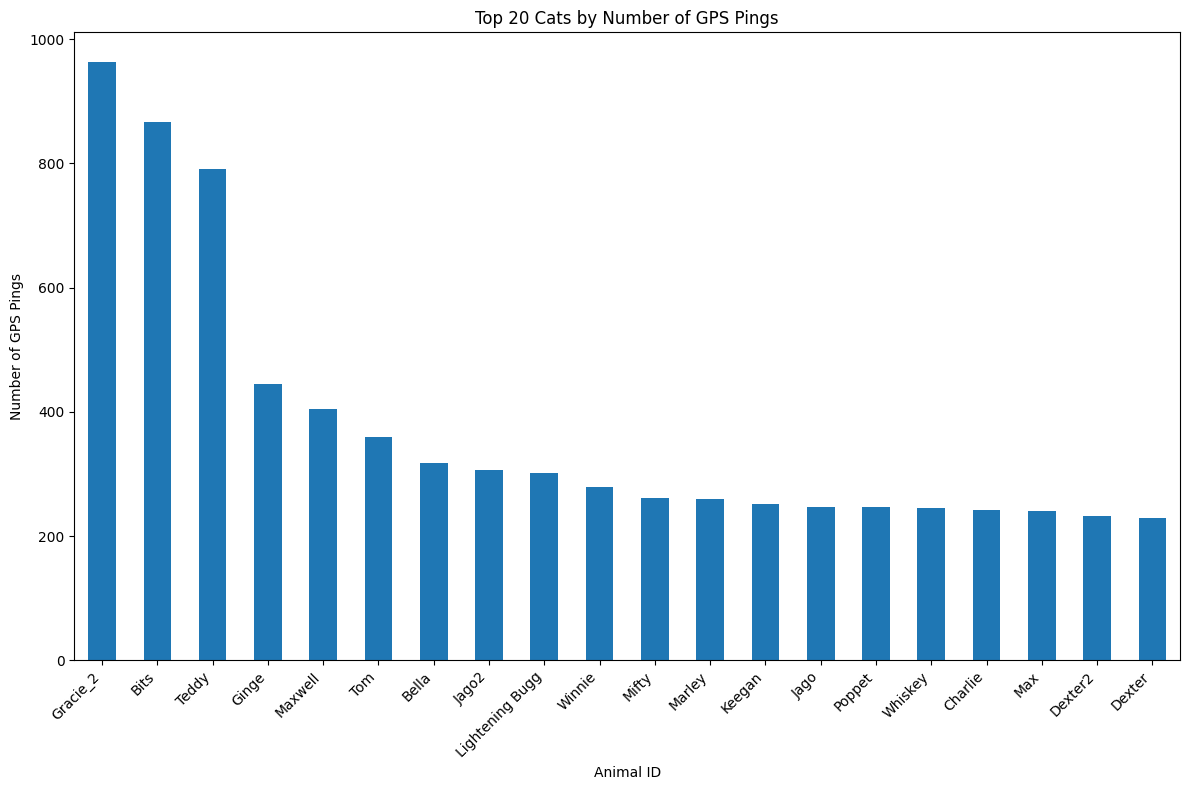

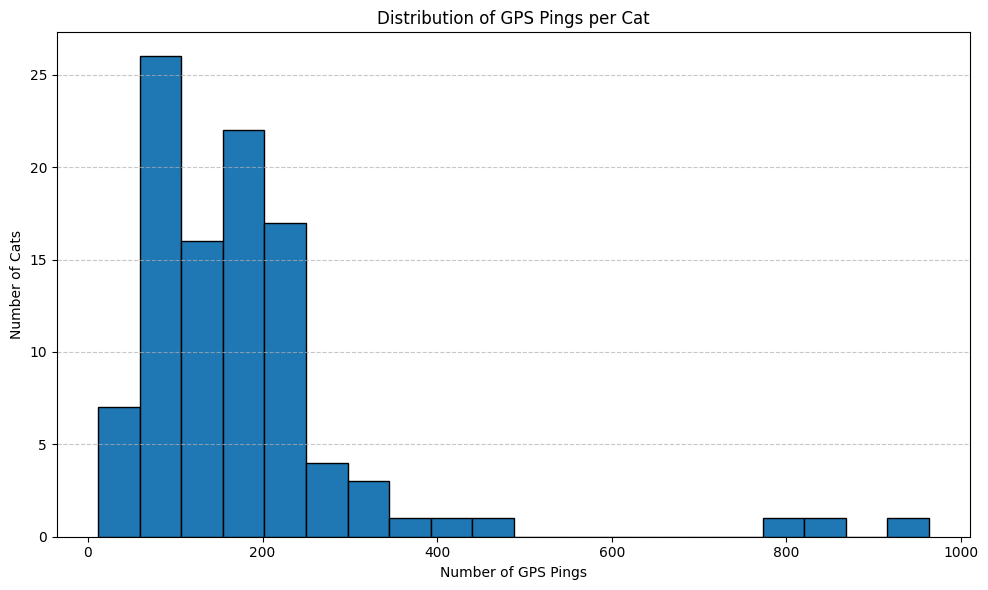

In [ ]:
# Get the distribution of track events by cats
pings_per_cat = cats_sum.groupby('animal_id')['event_id'].count().sort_values(ascending=False)

# Visualize the distribution using a bar chart for the top 20 cats
plt.figure(figsize=(12, 8))
pings_per_cat.head(20).plot(kind='bar') # Display top 20 for readability
plt.title('Top 20 Cats by Number of GPS Pings')
plt.xlabel('Animal ID')
plt.ylabel('Number of GPS Pings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Distribution of GPS Pings per cat
plt.figure(figsize=(10, 6))
plt.hist(pings_per_cat.values, bins=20, edgecolor='black')
plt.title('Distribution of GPS Pings per Cat')
plt.xlabel('Number of GPS Pings')
plt.ylabel('Number of Cats')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Per-cat deployment time coverage summary:
count    101.00
mean       7.02
std        3.34
min        0.51
25%        6.32
50%        6.98
75%        7.25
max       28.96
Name: days_covered_deployment, dtype: float64


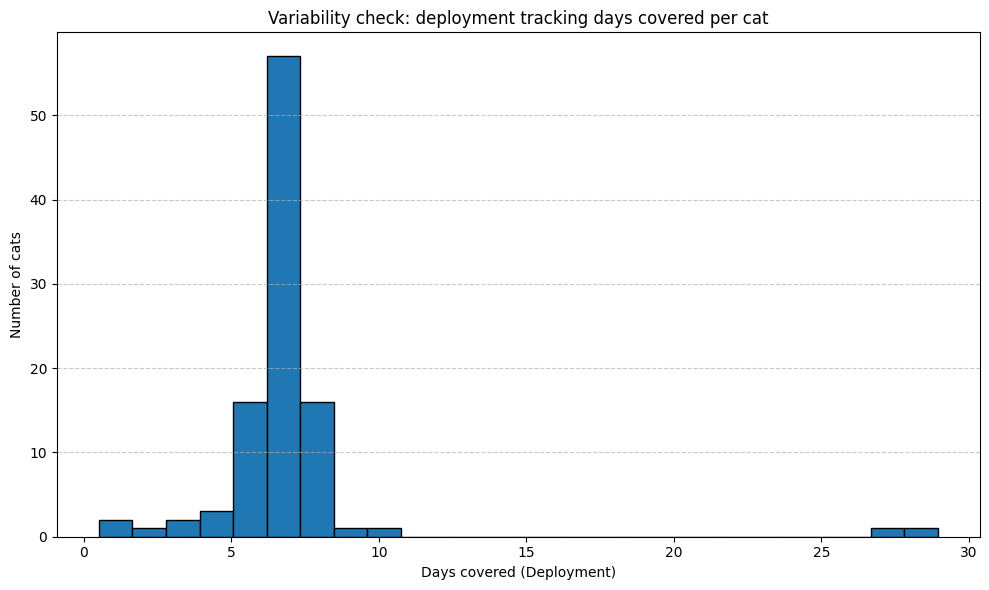

In [ ]:
# Time coverage variability by cat using the dataset cats_ref and columns of deploy_on_date, and deploy_off_date

cats_ref['deploy_on_date'] = pd.to_datetime(cats_ref['deploy_on_date'])
cats_ref['deploy_off_date'] = pd.to_datetime(cats_ref['deploy_off_date'])

# Calculate days covered based on deployment dates
cats_ref['days_covered_deployment'] = (cats_ref['deploy_off_date'] - cats_ref['deploy_on_date']).dt.total_seconds() / (3600 * 24)

print("\nPer-cat deployment time coverage summary:\n{}".format(cats_ref["days_covered_deployment"].describe().round(2)))

plt.figure(figsize=(10, 6))
plt.hist(cats_ref["days_covered_deployment"].dropna().values, bins=25, edgecolor='black')
plt.title("Variability check: deployment tracking days covered per cat")
plt.xlabel("Days covered (Deployment)")
plt.ylabel("Number of cats")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Gender Differences in Key Attributes

Let's visualize how `prey_p_month`, `age_years`, and `hunt` status vary between male and female cats. This will help us understand if there are any significant differences in hunting success, age distribution, or hunting propensity based on sex.

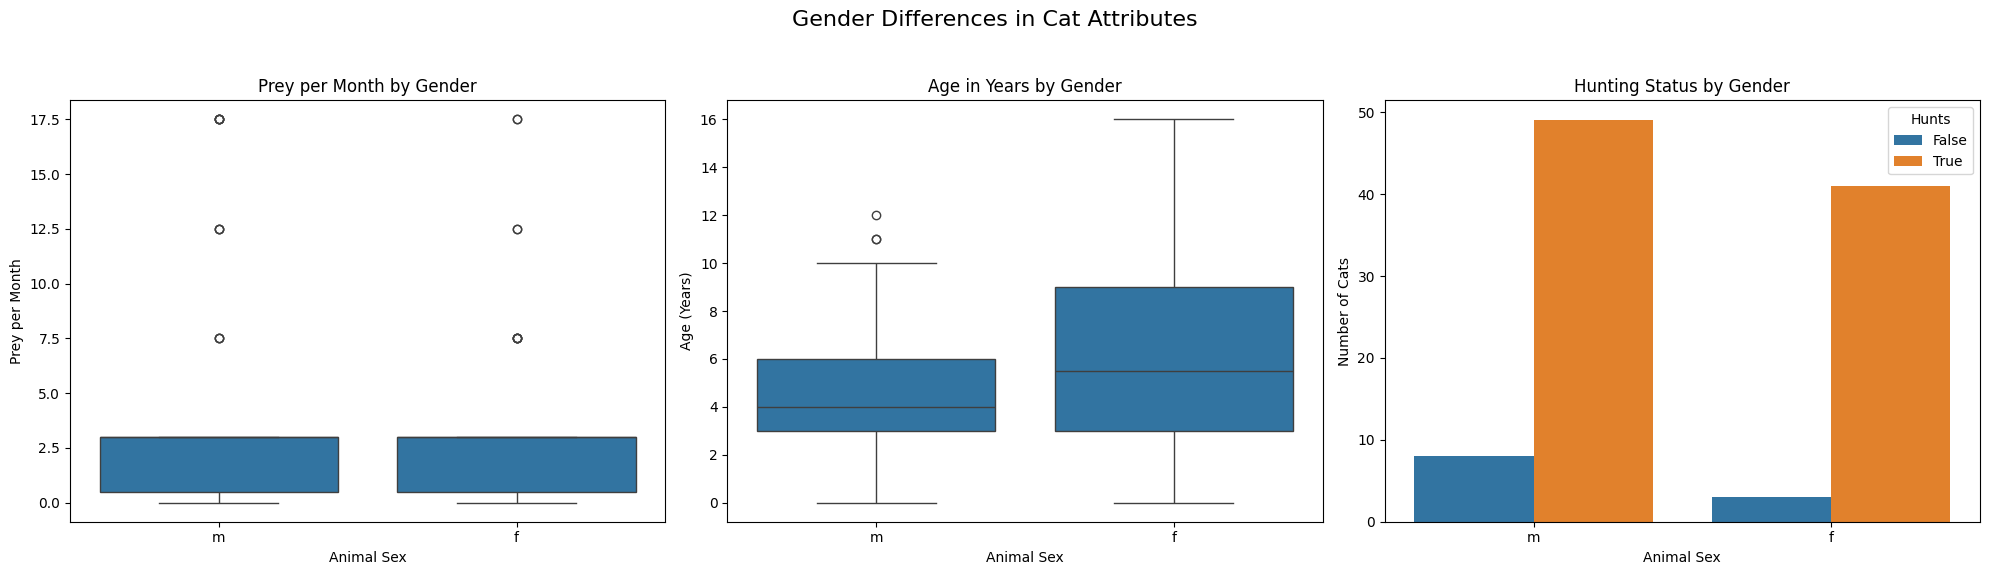

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Gender Differences in Cat Attributes', fontsize=16)

# Plot 1: prey_p_month by animal_sex (Box Plot)
sns.boxplot(x='animal_sex', y='prey_p_month', data=cats_ref, ax=axes[0])
axes[0].set_title('Prey per Month by Gender')
axes[0].set_xlabel('Animal Sex')
axes[0].set_ylabel('Prey per Month')

# Plot 2: age_years by animal_sex (Box Plot)
sns.boxplot(x='animal_sex', y='age_years', data=cats_ref, ax=axes[1])
axes[1].set_title('Age in Years by Gender')
axes[1].set_xlabel('Animal Sex')
axes[1].set_ylabel('Age (Years)')

# Plot 3: hunt status by animal_sex (Count Plot)
sns.countplot(x='animal_sex', hue='hunt', data=cats_ref, ax=axes[2])
axes[2].set_title('Hunting Status by Gender')
axes[2].set_xlabel('Animal Sex')
axes[2].set_ylabel('Number of Cats')
axes[2].legend(title='Hunts')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

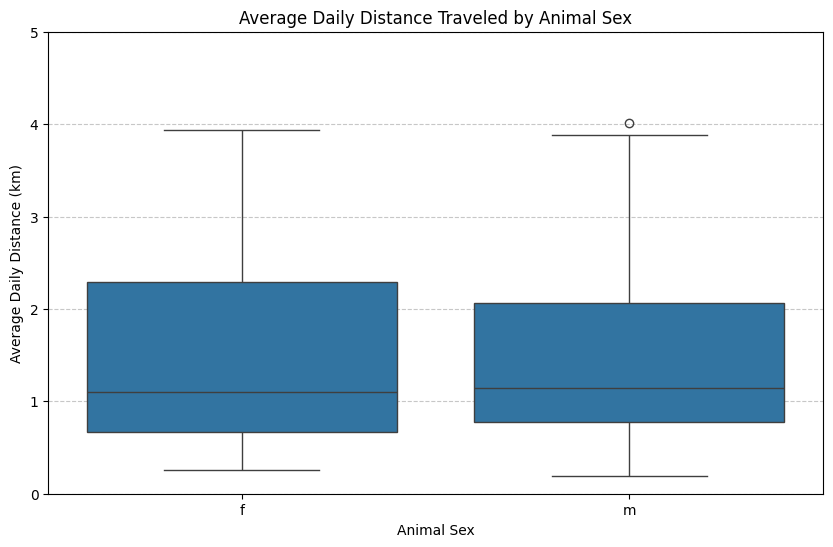

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert timestamp to datetime if not already done
cats_sum['timestamp'] = pd.to_datetime(cats_sum['timestamp'])

# Calculate approximate distance traveled for each ping
# This is a simplified calculation and might not be entirely accurate for geographical distances
cats_sum['prev_location_long'] = cats_sum.groupby('animal_id')['location_long'].shift(1)
cats_sum['prev_location_lat'] = cats_sum.groupby('animal_id')['location_lat'].shift(1)

cats_sum['distance_km'] = np.sqrt(
    (cats_sum['location_long'] - cats_sum['prev_location_long'])**2 +
    (cats_sum['location_lat'] - cats_sum['prev_location_lat'])**2
) * 111  # Approx km per degree lat/long

# Analyze average distance traveled per cat per day, grouped by animal sex
daily_summary = cats_sum.groupby(['animal_id', cats_sum['timestamp'].dt.date, 'animal_sex'])['distance_km'].sum().reset_index()
daily_summary = daily_summary.groupby(['animal_id', 'animal_sex'])['distance_km'].mean().reset_index()
daily_summary.rename(columns={'distance_km': 'avg_daily_distance_km'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.boxplot(x='animal_sex', y='avg_daily_distance_km', data=daily_summary)
plt.title('Average Daily Distance Traveled by Animal Sex')
plt.xlabel('Animal Sex')
plt.ylabel('Average Daily Distance (km)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 5)
plt.show()


Correlation among numeric cat-level variables:
              age_years  hrs_indoors  prey_p_month  n_cats
age_years          1.00         0.18         -0.15    0.16
hrs_indoors        0.18         1.00         -0.37    0.02
prey_p_month      -0.15        -0.37          1.00    0.00
n_cats             0.16         0.02          0.00    1.00


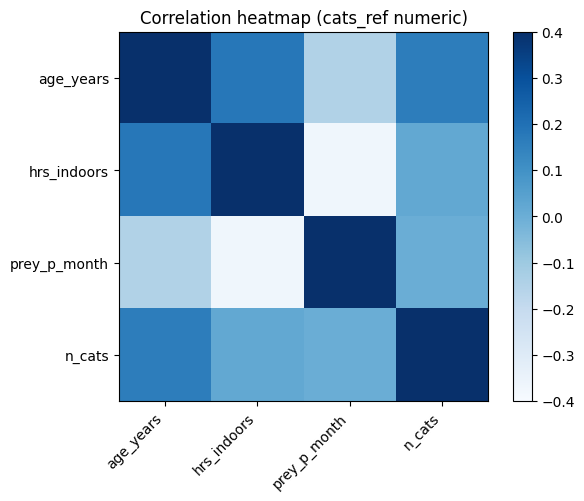


animal_sex distribution:
animal_sex
m    57
f    44
Name: count, dtype: int64

hunt distribution:
hunt
True     90
False    11
Name: count, dtype: int64

animal_reproductive_condition distribution:
animal_reproductive_condition
Fixed        99
Not fixed     2
Name: count, dtype: int64


In [ ]:
 # Correlation intuition on cat-level attributes (cats_ref)
num_cols = ["age_years", "hrs_indoors", "prey_p_month", "n_cats"]
num_cols = [c for c in num_cols if c in cats_ref.columns]

if len(num_cols) > 1:
    corr = cats_ref[num_cols].corr()
    print("\nCorrelation among numeric cat-level variables:\n{}".format(corr.round(2)))

    plt.figure()
    plt.imshow(corr.values, cmap="Blues", vmin=-0.4, vmax=0.4)
    plt.title("Correlation heatmap (cats_ref numeric)")
    plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
    plt.yticks(range(len(num_cols)), num_cols)
    plt.colorbar()
    plt.show()

# Imbalance in categories (sex / hunt)
for col in ["animal_sex", "hunt", "animal_reproductive_condition"]:
    if col in cats_ref.columns:
        print("\n{} distribution:\n{}".format(col, cats_ref[col].value_counts(dropna=False)))


Text(0, 0.5, 'count')

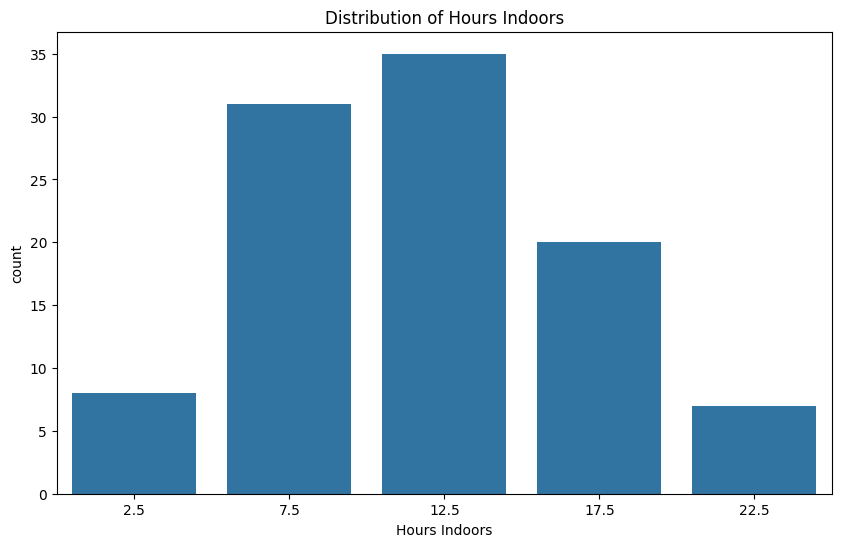

In [ ]:
# Explore the relationship between daily distance traveled and hours indoor

# Plot the indoor hour distribution of cats in the dataset cats_ref  by histogram
plt.figure(figsize=(10, 6))
sns.countplot(x='hrs_indoors', data=cats_ref)
plt.title('Distribution of Hours Indoors')
plt.xlabel('Hours Indoors')
plt.ylabel('count')


In [ ]:
# calculte the Distance traveled by each cat per day
# Convert timestamp to datetime if not already done
cats_sum['timestamp'] = pd.to_datetime(cats_sum['timestamp'])

# Calculate approximate distance traveled for each ping
# This is a simplified calculation and might not be entirely accurate for geographical distances
cats_sum['prev_location_long'] = cats_sum.groupby('animal_id')['location_long'].shift(1)
cats_sum['prev_location_lat'] = cats_sum.groupby('animal_id')['location_lat'].shift(1)

cats_sum['distance_km'] = np.sqrt(
    (cats_sum['location_long'] - cats_sum['prev_location_long'])**2 +
    (cats_sum['location_lat'] - cats_sum['prev_location_lat'])**2
) * 111  # Approx km per degree lat/long

# Analyze average distance traveled per cat per day
daily_summary = cats_sum.groupby(['animal_id', cats_sum['timestamp'].dt.date, 'animal_sex'])['distance_km'].sum().reset_index()
daily_summary = daily_summary.groupby(['animal_id', 'animal_sex'])['distance_km'].mean().reset_index()
daily_summary.rename(columns={'distance_km': 'avg_daily_distance_km'}, inplace=True)

print("daily_summary.head():")
print(daily_summary.head())
print("\ndaily_summary.info():")
print(daily_summary.info())

daily_summary.head():
  animal_id animal_sex  avg_daily_distance_km
0      Abba          f               0.714028
1     Alfie          m               1.805966
2     Amber          f               2.947721
3      Ares          m               0.748564
4    Athena          f               0.613512

daily_summary.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   animal_id              101 non-null    object 
 1   animal_sex             101 non-null    object 
 2   avg_daily_distance_km  101 non-null    float64
dtypes: float64(1), object(2)
memory usage: 2.5+ KB
None


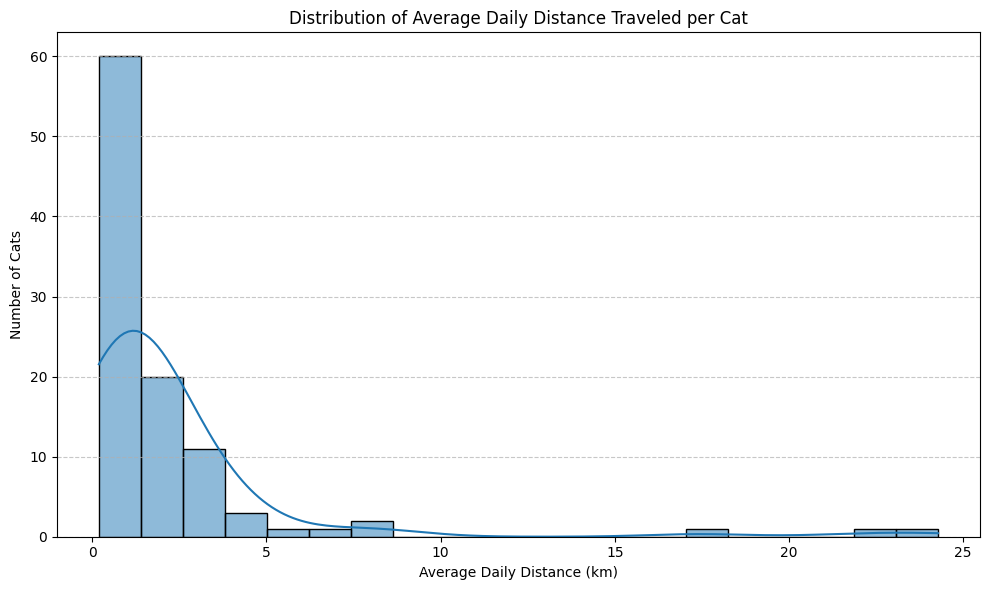

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram of avg_daily_distance_km
plt.figure(figsize=(10, 6))
sns.histplot(daily_summary['avg_daily_distance_km'].dropna(), bins=20, kde=True)
plt.title('Distribution of Average Daily Distance Traveled per Cat')
plt.xlabel('Average Daily Distance (km)')
plt.ylabel('Number of Cats')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Summary of Average Daily Distance Traveled

The histogram of `avg_daily_distance_km` reveals the distribution of how far cats, on average, travel per day:

*   **Right-Skewed Distribution**: The distribution is heavily right-skewed, indicating that a large number of cats travel relatively short distances on an average day. The majority of cats seem to stay close to home or have limited roaming ranges.
*   **Peak near Zero**: There's a prominent peak in the distribution at the lower end, suggesting that many cats have very small average daily travel distances, potentially indicating a more 'home-body' or indoor-oriented behavior.
*   **Long Tail**: A long tail extends to the right, showing that a smaller number of cats travel significantly larger distances daily. These could be 'explorer' cats or those with larger territories.
*   **Variety in Mobility**: The spread of the data indicates considerable variability in the mobility patterns among different cats, with some cats traveling less than 1 km per day on average, while others cover several kilometers.

This distribution highlights the diverse activity levels within the cat population, from those with minimal daily movement to those that are much more active outdoors.